# Figure 7 · The electrostatic channel, mode by mode, on a soft and a stiff probe

Production notebook for main-text Fig. 7 (Nature Communications style, 180 mm).

Data: two-domain bias surveys (8 positions × 7 biases × 2 domains, interleaved bias).
- **Soft probe** (PPP-CONTAu) at 15 nN and 250 nN, CR1–CR5.
- **Stiff probe** (SCM-PIT, run R2) at 500 nN, CR1–CR3; the repeat run R1 is in the SI. The per-position tables,
  lever frame and domain contact-potential term come from Fig. 6 (`results/fig6_main.json`).
- **Stiff probe** AC drive series at position A (R2 stage 70): 17 V_ac levels 2 mV–2 V,
  both domains, at 0 V and at the imaging null V̄ = 1.027 V.

Every channel uses the two-domain split of notebook 06: P = (a₁ − a₂)/2 flips with the domain,
b = (b₁ + b₂)/2 does not, and V_cpd = Re[−(a₁ + a₂)/2b].

**Soft-probe InvOLS.** Each stop's own value is read from its tune note (`calib.tune_invols`).
The survey log prints the previous stop's value, the same one-position lag as the stiff-probe
force-curve files: shifting the logged values by one stop makes them fit the static-shape law to
≤ 1.3 %, against 15–100 % unshifted. The earlier soft-probe d33 analysis (2026-09-19) used the
logged values, which is where its base-point "calibration mismatch" came from. The 15 nN survey
has no tune note at the free-end stop; that value is filled from the static-shape fit.

In [1]:
%matplotlib inline
import sys, pathlib
# make the paper package importable when running from notebooks/
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fmmpaper as F
from fmmpaper import io, axis, spectra, domains, recon, plotting as fp, results
fp.setup()
print(F.config.describe())

project : /home/claude/work/paper_analysis
data_root: /mnt/user-data/uploads/ActiveModeMap  (ok)
amm_repo : /home/claude/work  (ok)
eb_repo  : C:\Users\lz1\Documents\Github\EB-Solver-CResonance  (MISSING)
fmm_code_zip: /mnt/user-data/uploads/ActiveModeMap_repo/Manuscript_FMM/FMM_analysis_code.zip  (ok)


In [2]:
import json, datetime as dt, re, glob
from pathlib import Path
from fmmpaper import calib, eb_fit, registry
VAC = 1.0
F6 = json.loads((F.config.RESULTS_DIR / "fig6_main.json").read_text())["values"]
A_SOFT = 450.5            # soft probe: tip distance from the clamp (Phase 2g: L 463 um, setback 12.5 um)

def folder(key):
    return F.config.data_root() / Path(registry.DATASETS[key].path).parent

D = {}   # dataset -> dict(series, invols_fn, bands, x_norm, label)
for lab, key in (("soft, 15 nN", "ppp_bias_15nN"), ("soft, 250 nN", "ppp_bias_250nN")):
    s = F.load(key)
    fn, tinv = calib.tune_invols(folder(key))
    x0 = tinv.attrs["x0_um"]
    print(f"{lab}: clamp at stage {x0:.1f} um (static-shape fit); InvOLS shape residuals {tinv.shape_resid_pct.abs().max():.1f} % max; "
          f"free-end InvOLS {'filled' if 445.0 not in tinv.x_um.values else 'measured'} = {fn(445.0)*1e9:.0f} nm/V")
    D[lab] = dict(series=s, inv=fn, bands=["CR1", "CR2", "CR3", "CR4", "CR5"], xi=(s.x_um - x0) / A_SOFT, probe="soft")
for tag in ("R2",):                                      # run R1 (same lever) is in the SI
    s = F.load(f"scmpitB_{tag.lower()}_bias")
    t6 = pd.DataFrame(F6["runs"][tag]["table"])
    inv = dict(zip(t6.x_um.round(2), t6.invols))            # Fig. 6 per-stop InvOLS (force curve at each stop)
    D["stiff, 500 nN"] = dict(series=s, inv=lambda x, _i=inv: _i[round(float(x), 2)], bands=["CR1", "CR2", "CR3"],
                              xi=t6.x_lever_um.values / F6["runs"][tag]["contact_um"], probe="stiff", tag=tag)
COL = {"soft, 15 nN": "#fdae6b", "soft, 250 nN": "#d95f02", "stiff, 500 nN": "#1b9e77"}

soft, 15 nN: clamp at stage -27.0 um (static-shape fit); InvOLS shape residuals 1.3 % max; free-end InvOLS filled = 489 nm/V


soft, 250 nN: clamp at stage -18.4 um (static-shape fit); InvOLS shape residuals 1.3 % max; free-end InvOLS measured = 500 nm/V


## Per-mode channel tables
For every dataset and mode: P and b at the mode's peak (0 V, domain-1 spectrum), |b|/|P|, V_cpd,
and the quasi-static channel (15–45 kHz mean). Then the domain contact-potential term δ is fitted
in the quasi-static channel exactly as in Fig. 6 (`domains.cpd_split`, uniform d33 assumed).

In [3]:
rows, QS, CPD = [], {}, {}
for lab, d in D.items():
    s = d["series"]
    for b in d["bands"]:
        t = domains.transfer_table(s, d["inv"], VAC, cr_band=b)
        for i, r in t.iterrows():
            rows.append(dict(dataset=lab, probe=d["probe"], mode=b, n=int(b[2]), i=i, xi=d["xi"][i], f_kHz=r.f_cr_Hz / 1e3,
                             ratio=r.ratio_cr, vcpd=r.vcpd_cr, P_over_b=1 / r.ratio_cr))
        if b == "CR1":
            QS[lab] = t.assign(xi=d["xi"])
    t = QS[lab]
    keep = d["xi"] < 0.97                                # drop the stop at/after the tip contact, as in Fig. 6
    if d["probe"] == "soft":
        cs = domains.cpd_split(t, mask=keep)
        cs_all = domains.cpd_split(t)
        CPD[lab] = dict(delta_V=cs["delta_V"], dV_domains_V=cs["dV_domains_V"], d33_uniform=cs["d33_uniform"],
                        xi=d["xi"][keep], d33_raw=t.d33_qs.values[keep], d33_corr=cs["d33_qs_corr"][keep],
                        d33_uniform_all_stops=cs_all["d33_uniform"])
    else:                                                # stiff probe: exactly the Fig. 6 numbers
        tag = d["tag"]; t6 = pd.DataFrame(F6["runs"][tag]["table"]); t6 = t6[t6.interior]
        c6 = F6["runs"][tag]["cpd"]
        CPD[lab] = dict(delta_V=c6["delta_V"], dV_domains_V=c6["dV_domains_V"], d33_uniform=c6["d33_uniform"],
                        xi=(t6.x_lever_um / F6["runs"][tag]["contact_um"]).values, d33_raw=t6.d33_qs_raw.values,
                        d33_corr=t6.d33_qs.values, d33_uniform_all_stops=np.nan)
modes = pd.DataFrame(rows)
cp = pd.DataFrame({k: dict(delta_mV=1e3 * v["delta_V"], V1_minus_V2_V=v["dV_domains_V"], d33_uniform=v["d33_uniform"],
                           d33_uniform_all_stops=v["d33_uniform_all_stops"],
                           raw_max_over_min=v["d33_raw"].max() / v["d33_raw"].min(),
                           corr_sd_pct=100 * np.std(v["d33_corr"]) / np.mean(v["d33_corr"]),
                           corr_max_over_min=v["d33_corr"].max() / v["d33_corr"].min()) for k, v in CPD.items()}).T
cp.round(3)

,delta_mV,V1_minus_V2_V,d33_uniform,d33_uniform_all_stops,raw_max_over_min,corr_sd_pct,corr_max_over_min
"soft, 15 nN",-152.794,0.306,5.920,5.678,1.674,4.429,1.136
"soft, 250 nN",-318.540,0.637,6.911,6.626,2.058,3.993,1.124
"stiff, 500 nN",635.455,-1.271,7.579,NaN,1.282,0.838,1.030


**Soft probe, domain contact potential.** On the soft lever the electrostatic slope b is 3–7×
larger than on the stiff one, so the same kind of domain contact-potential difference produces
a much larger spurious term in P. The raw quasi-static d33 falls 1.9× (15 nN) and 2.6× (250 nN)
from base to tip; one δ per survey removes that fall to within a few per cent. This is the
"shape-model discrepancy" of the earlier soft-probe analysis: it was the domain contact potential,
not the lever.

In [4]:
summ = (modes.groupby(["dataset", "mode"])
        .agg(f_kHz=("f_kHz", "median"), ratio_med=("ratio", "median"), ratio_lo=("ratio", "min"), ratio_hi=("ratio", "max"),
             vcpd_med=("vcpd", "median"), vcpd_sd=("vcpd", "std")).reset_index())
for lab, t in QS.items():
    summ = pd.concat([summ, pd.DataFrame([dict(dataset=lab, mode="QS", f_kHz=30.0, ratio_med=np.median(t.ratio_qs), ratio_lo=t.ratio_qs.min(),
                                                ratio_hi=t.ratio_qs.max(), vcpd_med=np.median(t.vcpd_qs[D[lab]['xi'] < 0.9]),
                                                vcpd_sd=np.std(t.vcpd_qs[D[lab]['xi'] < 0.9]))])])
summ.round(3)

,dataset,mode,f_kHz,ratio_med,ratio_lo,ratio_hi,vcpd_med,vcpd_sd
0,"soft, 15 nN",CR1,64.077,1.461,1.213,1.933,1.495,0.054
1,"soft, 15 nN",CR2,200.075,0.240,0.151,0.319,1.623,0.214
2,"soft, 15 nN",CR3,409.775,0.124,0.038,0.133,2.335,0.668
3,"soft, 15 nN",CR4,682.583,0.066,0.059,0.071,3.392,0.919
4,"soft, 15 nN",CR5,986.096,0.051,0.039,0.057,2.994,1.245
5,"soft, 250 nN",CR1,65.367,0.960,0.905,0.983,0.960,0.056
6,"soft, 250 nN",CR2,202.443,0.166,0.153,0.192,1.308,0.243
7,"soft, 250 nN",CR3,415.307,0.082,0.066,0.088,3.091,0.809
8,"soft, 250 nN",CR4,697.777,0.045,0.044,0.048,6.046,1.578
9,"soft, 250 nN",CR5,1035.003,0.037,0.035,0.039,7.701,1.757


## AC drive series (stiff probe B, R2, position A)
Two-domain split with the two biases of each spot (0 V and V̄), then the domain contact-potential
term removed with R2's δ from Fig. 6. CR1 is read at the fixed CR1 frequency of the 1 V spectrum,
as in fixed-frequency imaging (a peak search at the lowest drives locks onto noise). CR1 is
divided by the blind-EB enhancement at A's lever position at the time of the series.

In [5]:
ACDIR = F.config.data_root() / registry.DATASETS["scmpitB_r2_ac_series"].path
files = sorted(ACDIR.glob("ac_series_A_vac*_checkpoint.npz"))
camp, d0 = "DomainsB_SCMPIT_R2", dt.datetime(2026, 9, 20, 22)
tl = calib.timeline(camp, d0); an = calib.frame_anchors(camp, tl, 226.5)
t70 = tl[tl.stage == "70_ac_series"].t.median()
x0_70 = float(calib.x0_at(an, t70)[0]); X_A = 154.9; xA = X_A - x0_70
pre = axis.invols_interpolator(F.load("scmpitB_r2_preflight"))
invA = float(np.atleast_1d(pre(X_A))[0]) * float(calib.factor_at(tl, "70_ac_series", X_A)[0])
pR2 = np.array(F6["runs"]["R2"]["fit"]["central"]["p"])
E_A = float(eb_fit.enhancement(pR2, eb_fit.ContactState("R2", np.zeros(3), 0.0, np.array([]), np.array([])), [xA])[0][0])
dR2 = F6["runs"]["R2"]["cpd"]["delta_V"]
d1000 = np.load(next(f for f in files if "vac1000" in f.name), allow_pickle=True)
fq = d1000["freq_Hz"]; kCR = spectra.peak(fq, d1000["Z"][1, 0], (255e3, 330e3))["k"]
qs = (fq > 15e3) & (fq < 45e3)
ac = []
for f in files:
    d = np.load(f, allow_pickle=True); vac = float(re.search(r"vac(\d+\.\d+)mV", f.name)[1]) / 1e3
    cond = json.loads(str(d["conditions"])); Z = d["Z"][:, 0]
    V = np.array([c["bias_V"] for c in cond]); sp = np.array([c["spot"] for c in cond])
    conv = invA / 32 / vac * 1e12
    out = dict(vac_V=vac)
    for ch, z in (("qs", Z[:, qs].mean(1)), ("cr", Z[:, kCR])):
        r = domains.decompose(V[sp == 1], z[sp == 1], V[sp == 2], z[sp == 2])
        out[f"{ch}_raw"] = abs(r["P"]) * conv
        out[f"{ch}"] = abs(r["P"] - dR2 * r["b"]) * conv
        out[f"{ch}_spot1_Vbar"] = abs(z[(sp == 1) & (V > 0.5)][0]) * conv
        out[f"{ch}_spot2_Vbar"] = abs(z[(sp == 2) & (V > 0.5)][0]) * conv
    # noise equivalent of the band-averaged QS channel: standard error of the 15-45 kHz mean, averaged over conditions
    out["qs_noise"] = float(np.mean(np.std(Z[:, qs], axis=1) / np.sqrt(qs.sum()))) * conv
    ac.append(out)
ac = pd.DataFrame(ac).sort_values("vac_V").reset_index(drop=True)
# measured enhancement at A: the bias survey's own E(x) = |P_CR1|/|P_QS|, interpolated (log) to A's lever position.
# Independent of the AC series; the AC series' own CR1/QS ratio (V_ac >= 0.1 V) is printed as a check.
_t6 = pd.DataFrame(F6["runs"]["R2"]["table"])
E_M = float(np.exp(np.interp(xA, _t6.x_lever_um, np.log(_t6.E))))
ac["cr_over_E"] = ac.cr / E_M
ac["cr_over_EEB"] = ac.cr / E_A
print(f"E at A: measured (survey) {E_M:.0f}, blind EB {E_A:.0f}, AC-series own CR1/QS (>= 0.1 V) {np.median((ac.cr / ac.qs)[ac.vac_V >= 0.1]):.0f}")
# noise-floor model on the single-spot CR1 amplitude: |Z| = sqrt((k V)^2 + n0^2)  ->  per volt: sqrt(k^2 + (n0/V)^2)
from scipy.optimize import curve_fit
NF = {}
for spn in (1, 2):
    y = ac[f"cr_spot{spn}_Vbar"].values * ac.vac_V.values          # pm
    (k, n0), _ = curve_fit(lambda v, k, n0: np.sqrt((k * v) ** 2 + n0 ** 2), ac.vac_V.values, y, p0=(2500, 5))
    NF[spn] = (abs(k), abs(n0))
print(f"A: lever position {xA:.1f} um at the AC series (x0 {x0_70:.1f} um), InvOLS {invA*1e6:.3f} um/V, E_EB {E_A:.0f}")
print("noise-floor fits (single spot, CR1 at Vbar):", {s: f"k {k:.0f} pm/V, n0 {n0:.2f} pm, crossover {1e3*n0/k:.1f} mV" for s, (k, n0) in NF.items()})
hi = ac.vac_V >= 0.05
print(f"V_ac >= 50 mV: QS {ac.qs[hi].mean():.2f} +- {ac.qs[hi].std():.2f}, CR1/E_meas {ac.cr_over_E[hi].mean():.2f} +- {ac.cr_over_E[hi].std():.2f}, CR1/E_EB {ac.cr_over_EEB[hi].mean():.2f} +- {ac.cr_over_EEB[hi].std():.2f} pm/V")
ac.round(3)

E at A: measured (survey) 274, blind EB 296, AC-series own CR1/QS (>= 0.1 V) 251
A: lever position 128.6 um at the AC series (x0 26.3 um), InvOLS 1.259 um/V, E_EB 296
noise-floor fits (single spot, CR1 at Vbar): {1: 'k 2787 pm/V, n0 18.32 pm, crossover 6.6 mV', 2: 'k 2169 pm/V, n0 12.66 pm, crossover 5.8 mV'}
V_ac >= 50 mV: QS 7.33 +- 0.33, CR1/E_meas 6.84 +- 0.36, CR1/E_EB 6.32 +- 0.33 pm/V


,vac_V,qs_raw,qs,qs_spot1_Vbar,qs_spot2_Vbar,cr_raw,cr,cr_spot1_Vbar,cr_spot2_Vbar,qs_noise,cr_over_E,cr_over_EEB
0,0.002,45.269,49.348,30.679,33.837,6774.967,5167.015,3237.225,3119.934,16.720,18.888,17.476
1,0.003,15.964,16.082,8.058,9.241,5794.031,4401.318,4081.719,6364.979,9.515,16.089,14.886
2,0.005,16.248,19.933,14.165,3.402,1060.006,2982.403,7628.591,5705.023,6.537,10.902,10.087
3,0.010,10.533,17.918,15.327,17.002,1463.185,651.916,5081.036,1914.185,2.879,2.383,2.205
4,0.020,8.076,7.380,6.526,8.714,2078.052,1633.651,3464.769,2174.571,1.542,5.972,5.525
5,0.030,8.831,7.552,10.925,8.095,2135.210,1814.792,2671.102,1775.000,1.038,6.634,6.138
6,0.050,8.273,6.649,9.025,8.259,2337.107,2051.322,2432.141,2217.265,0.599,7.498,6.938
7,0.075,8.851,7.611,7.980,9.616,2192.275,1759.541,2801.216,2203.815,0.404,6.432,5.951
8,0.100,8.204,6.858,7.908,8.537,2252.304,1812.659,2495.009,2091.529,0.323,6.626,6.131
9,0.150,8.932,7.425,9.122,8.549,2292.433,1975.907,2805.908,2136.881,0.223,7.223,6.683


## The figure

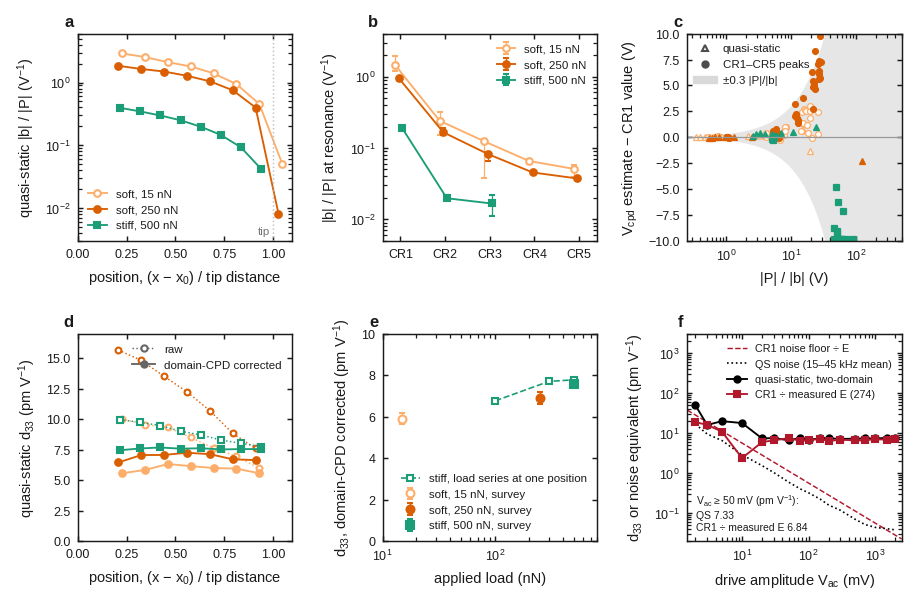

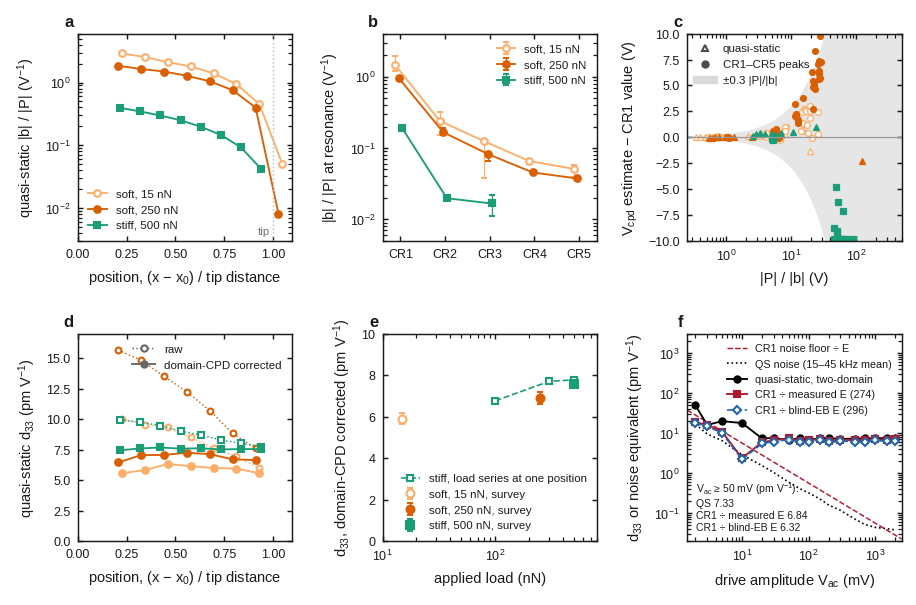

In [6]:
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
def make(BOTH, NAME):
    fig = plt.figure(figsize=(fp.WIDTH_IN["double"], fp.WIDTH_IN["double"] * 0.62))
    gs = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.42)
    ax = {k: fig.add_subplot(gs[i // 3, i % 3]) for i, k in enumerate("abcdef")}
    MK = {"soft, 15 nN": "o", "soft, 250 nN": "o", "stiff, 500 nN": "s"}
    MFC = lambda lab: "w" if lab.endswith("15 nN") else COL[lab]

    # a  quasi-static electrostatic/piezo ratio along the lever: blind spot at the tip
    a = ax["a"]
    for lab, t in QS.items():
        a.semilogy(t.xi, t.ratio_qs, marker=MK[lab], color=COL[lab], mfc=MFC(lab), ms=3.2, lw=0.9, label=lab)
    a.axvline(1.0, color="0.75", lw=0.7, ls=":")
    a.text(0.985, 0.02, "tip", transform=a.get_xaxis_transform(), ha="right", va="bottom", fontsize=5.5, color="0.45")
    a.set_xlim(0, 1.1); a.set_ylim(3e-3, 6)
    a.set_xlabel("position, (x − x$_0$) / tip distance"); a.set_ylabel("quasi-static |b| / |P| (V$^{-1}$)")
    a.legend(loc="lower left", fontsize=5.5, handlelength=1.6)
    fp.panel_label(a, "a")

    # b  |b|/|P| at resonance vs mode number
    b = ax["b"]
    for j, (lab, g) in enumerate(summ[summ["mode"] != "QS"].groupby("dataset", sort=False)):
        n = g["mode"].str[2].astype(int).values + (j - 1.5) * 0.08
        b.errorbar(n, g.ratio_med, yerr=[g.ratio_med - g.ratio_lo, g.ratio_hi - g.ratio_med], fmt=MK[lab] + "-", color=COL[lab],
                   mfc=MFC(lab), ms=3.2, lw=0.9, capsize=1.5, elinewidth=0.6, label=lab)
    b.set_yscale("log"); b.set_xticks(range(1, 6)); b.set_xticklabels([f"CR{i}" for i in range(1, 6)]); b.set_xlim(0.6, 5.4)
    b.set_ylim(5e-3, 4); b.set_ylabel("|b| / |P| at resonance (V$^{-1}$)")
    b.legend(loc="upper right", fontsize=5.5, handlelength=1.6)
    fp.panel_label(b, "b")

    # c  V_cpd estimate vs |P|/|b|: measurable only where the electrostatic channel is strong
    c = ax["c"]
    pts = pd.concat([modes[["dataset", "P_over_b", "vcpd"]].assign(ch="CR"),
                     pd.concat([pd.DataFrame(dict(dataset=lab, P_over_b=1 / t.ratio_qs.values, vcpd=t.vcpd_qs.values)) for lab, t in QS.items()]).assign(ch="QS")])
    VREF = modes[modes["mode"] == "CR1"].groupby("dataset").vcpd.median()
    pts["dev"] = pts.vcpd - pts.dataset.map(VREF)
    ETA = 0.3
    xx = np.logspace(-0.6, 2.7, 60)
    c.fill_between(xx, -ETA * xx, ETA * xx, color="0.9", lw=0, zorder=0)
    for lab in D:
        for ch, mk in (("QS", "^"), ("CR", MK[lab])):
            p = pts[(pts.dataset == lab) & (pts.ch == ch)]
            c.semilogx(p.P_over_b, np.clip(p.dev, -9.8, 9.8), mk, color=COL[lab], mfc=MFC(lab), ms=2.8, mew=0.6, lw=0)
    c.axhline(0, color="0.6", lw=0.6)
    c.set_xlim(0.25, 500); c.set_ylim(-10, 10)
    c.set_xlabel("|P| / |b| (V)"); c.set_ylabel("V$_{cpd}$ estimate − CR1 value (V)")
    c.legend(handles=[Line2D([], [], marker="^", ls="", color="0.3", mfc="w", ms=3, label="quasi-static"),
                      Line2D([], [], marker="o", ls="", color="0.3", ms=3, label="CR1–CR5 peaks"),
                      Line2D([], [], color="0.85", lw=4, label=f"±{ETA} |P|/|b|")], loc="upper left", fontsize=5.5, handlelength=1.4)
    fp.panel_label(c, "c")

    # d  quasi-static d33 along the lever, raw vs domain-CPD corrected, both probes
    dd = ax["d"]
    for lab, v in CPD.items():
        dd.plot(v["xi"], v["d33_raw"], marker=MK[lab], ls=":", color=COL[lab], mfc="w", ms=2.8, lw=0.7)
        dd.plot(v["xi"], v["d33_corr"], marker=MK[lab], ls="-", color=COL[lab], mfc=COL[lab], ms=3.2, lw=0.9, label=lab)
    dd.set_xlim(0, 1.1); dd.set_ylim(0, 17)
    dd.set_xlabel("position, (x − x$_0$) / tip distance"); dd.set_ylabel("quasi-static d$_{33}$ (pm V$^{-1}$)")
    dd.legend(handles=[Line2D([], [], marker="o", ls=":", color="0.4", mfc="w", ms=3, lw=0.7, label="raw"),
                       Line2D([], [], marker="o", ls="-", color="0.4", ms=3, lw=0.9, label="domain-CPD corrected")],
              loc="upper right", fontsize=5.5, handlelength=2)
    fp.panel_label(dd, "d")

    # e  d33 vs load, both probes
    e = ax["e"]
    for lab, v in CPD.items():
        load = float(lab.split(", ")[1].split()[0])
        y = pd.Series(v["d33_corr"])
        e.errorbar(load, y.mean(), yerr=y.std(), fmt=MK[lab], color=COL[lab], mfc=MFC(lab), ms=3.8,
                   capsize=1.5, elinewidth=0.7, label=f"{lab}, survey")
    lx = pd.DataFrame(F6["load"])
    e.plot(lx.load_nN, lx.d33_corr, "s--", color=COL["stiff, 500 nN"], mfc="w", ms=3.2, lw=0.8, label="stiff, load series at one position")
    e.set_xscale("log"); e.set_xlim(10, 800); e.set_ylim(0, 10)
    e.set_xlabel("applied load (nN)"); e.set_ylabel("d$_{33}$, domain-CPD corrected (pm V$^{-1}$)")
    e.legend(loc="lower right", fontsize=5.5, handlelength=1.6)
    fp.panel_label(e, "e")

    # f  AC drive series at A: both channels linear down to ~20 mV
    f_ = ax["f"]
    vv = np.logspace(np.log10(1.5e-3), np.log10(2.5), 80)
    n0 = np.mean([v[1] for v in NF.values()])
    f_.loglog(vv * 1e3, n0 / vv / E_M, "--", color=fp.C["ebgp"], lw=0.7, label="CR1 noise floor ÷ E")
    f_.loglog(ac.vac_V * 1e3, ac.qs_noise, ":", color="k", lw=0.8, label="QS noise (15–45 kHz mean)")
    f_.loglog(ac.vac_V * 1e3, ac.qs, "o-", color="k", ms=3, lw=0.9, label="quasi-static, two-domain")
    f_.loglog(ac.vac_V * 1e3, ac.cr_over_E, "s-", color=fp.C["ebgp"], ms=3, lw=0.9, label=f"CR1 ÷ measured E ({E_M:.0f})")
    if BOTH:
        f_.loglog(ac.vac_V * 1e3, ac.cr_over_EEB, "D--", color=fp.C["gp"], mfc="w", ms=2.6, lw=0.8, label=f"CR1 ÷ blind-EB E ({E_A:.0f})")
    _t = f"V$_{{ac}}$ ≥ 50 mV (pm V$^{{-1}}$):\nQS {ac.qs[hi].mean():.2f}\nCR1 ÷ measured E {ac.cr_over_E[hi].mean():.2f}"
    if BOTH:
        _t += f"\nCR1 ÷ blind-EB E {ac.cr_over_EEB[hi].mean():.2f}"
    f_.text(0.04, 0.04, _t, transform=f_.transAxes, fontsize=5, va="bottom", linespacing=1.25)
    f_.set_xlim(1.5, 2500); f_.set_ylim(0.02, 3000)
    f_.set_xlabel("drive amplitude V$_{ac}$ (mV)"); f_.set_ylabel("d$_{33}$ or noise equivalent (pm V$^{-1}$)")
    f_.legend(loc="upper right", fontsize=5.2, handlelength=1.8)
    fp.panel_label(f_, "f")
    fp.save(fig, NAME)

make(False, "Fig7_electrostatic_channel")          # main: CR1 divided by the measured E
make(True, "Fig7_electrostatic_channel_f_bothE")   # review: measured E and blind-EB E

In [7]:
results.save("fig7_main", dict(cpd={k: {kk: vv for kk, vv in v.items()} for k, v in CPD.items()},
                               cpd_table=cp.reset_index().rename(columns={"index": "dataset"}).to_dict("records"),
                               modes_summary=summ.to_dict("records"),
                               ac_series=dict(x_lever_A_um=xA, invols_A_m_per_V=invA, E_EB_A=E_A, E_meas_A=E_M, delta_V=dR2,
                                              noise_floor={str(k): dict(k_pm_per_V=v[0], n0_pm=v[1], crossover_mV=1e3 * v[1] / v[0]) for k, v in NF.items()},
                                              table=ac.to_dict("records"))),
             table=modes)

PosixPath('/home/claude/work/paper_analysis/results/fig7_main.json')